# Step 4: Real Spatial Data (No Fake Sensors)

## Why this notebook exists

The earlier pipeline built a **fake triangle** around each reef and added random ±0.2°C noise.
That was fine for demos — but the model was not learning real spatial differences.

Here we use the **5 real satellite locations** already in `sliot_dataset/`:

| Location | Approx coords |
|----------|---------------|
| Hikkaduwa | 6.125°N, 80.075°E |
| Kalpitiya | 8.375°N, 79.725°E |
| Passikudah | 7.925°N, 81.575°E |
| South East | 6.175°N, 81.475°E |
| Trincomalee | 8.725°N, 81.175°E |

**What you get:** clean SST + DHW tables, scalers, and **time / location hold-out splits** ready for training.

## What changed vs the old approach

```
OLD (demo)                         NEW (this notebook)
-------------                      -------------------
1 SST series                       5 real reef sites
+ triangle offsets                 real lat/lon only
+ random ±0.2°C noise              no synthetic noise
shuffled / prefix split            hold out future dates
                                   + leave one location out
```

## Import libraries

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from prepare_data import (
    LOCATIONS,
    load_all_locations,
    prepare_and_save,
    time_holdout_split,
    location_holdout_split,
)

print("Libraries loaded")
print("Locations:", LOCATIONS)

Libraries loaded
Locations: ['hikkaduwa', 'kalpitiya', 'passikudha', 'south_east', 'trinco']


## Load real multi-location SST + DHW

Each site already has `sst_full.csv` and `dhw_full.csv`.
We merge them on time — **no triangle offsets, no random noise**.

In [2]:
df = load_all_locations()

print("Combined shape:", df.shape)
print("Date range:", df["time"].min(), "→", df["time"].max())
print("\nRows per location:")
print(df.groupby("location").size())
df.head()

Combined shape: (20095, 7)
Date range: 2015-03-01 12:00:00+00:00 → 2026-03-01 12:00:00+00:00

Rows per location:
location
hikkaduwa     4019
kalpitiya     4019
passikudha    4019
south_east    4019
trinco        4019
dtype: int64


,time,latitude,longitude,analysed_sst,degree_heating_week,location,days
0,2015-03-01 12:00:00+00:00,6.125,80.075,29.06,0.0,hikkaduwa,0.0
1,2015-03-01 12:00:00+00:00,8.375,79.725,28.48,0.0,kalpitiya,0.0
2,2015-03-01 12:00:00+00:00,7.925,81.575,28.57,0.0,passikudha,0.0
3,2015-03-01 12:00:00+00:00,6.175,81.475,29.06,0.0,south_east,0.0
4,2015-03-01 12:00:00+00:00,8.725,81.175,28.60,0.0,trinco,0.0


## Peek at real spatial differences

If the sites were just copies of one series, mean temperatures would be almost identical.
Real satellite points should differ by location.

In [3]:
summary = (
    df.groupby("location")
    .agg(
        lat=("latitude", "first"),
        lon=("longitude", "first"),
        sst_mean=("analysed_sst", "mean"),
        sst_std=("analysed_sst", "std"),
        dhw_mean=("degree_heating_week", "mean"),
        dhw_max=("degree_heating_week", "max"),
    )
    .round(3)
)
summary

,lat,lon,sst_mean,sst_std,dhw_mean,dhw_max
location,,,,,,
hikkaduwa,6.125,80.075,28.724,0.824,0.514,10.06
kalpitiya,8.375,79.725,28.692,1.028,0.556,9.93
passikudha,7.925,81.575,29.050,0.970,0.087,3.84
south_east,6.175,81.475,28.464,0.929,0.453,9.27
trinco,8.725,81.175,28.841,0.982,0.088,3.89


## Visualize SST time series per reef

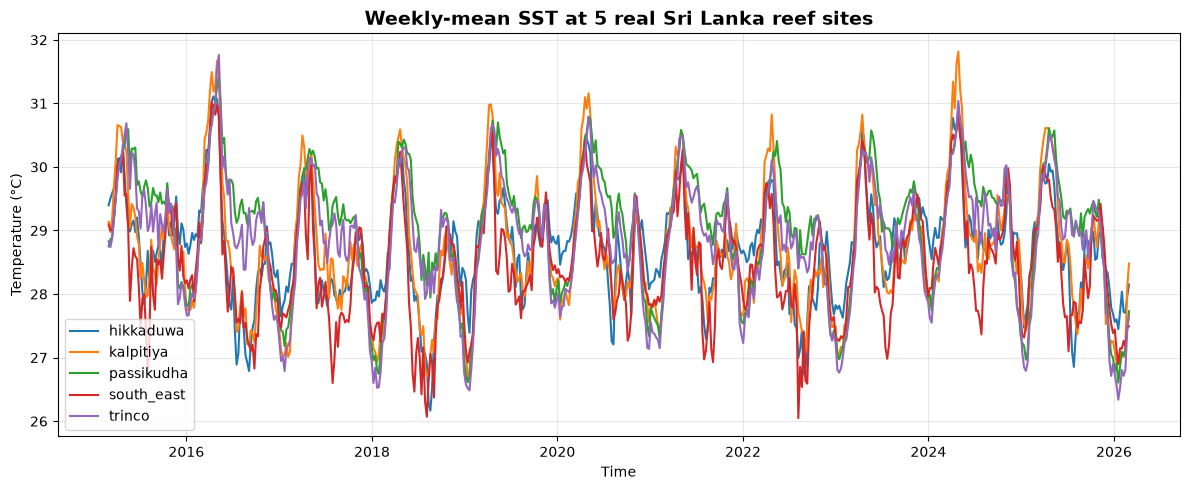

In [4]:
fig, ax = plt.subplots(figsize=(12, 5))
for loc, g in df.groupby("location"):
    # Plot a weekly downsample so the chart stays readable
    g2 = g.set_index("time")["analysed_sst"].resample("7D").mean()
    ax.plot(g2.index, g2.values, label=loc, linewidth=1.5)

ax.set_title("Weekly-mean SST at 5 real Sri Lanka reef sites", fontsize=14, fontweight="bold")
ax.set_ylabel("Temperature (°C)")
ax.set_xlabel("Time")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Hold-out strategy (important!)

A shuffled 80/20 split **leaks the future into training**.

We do two tougher checks instead:

1. **Time hold-out** — train on older dates, validate/test on the newest dates
2. **Location hold-out** — leave one reef (default: Trincomalee) completely out of training

In [5]:
train_t, val_t, test_t = time_holdout_split(df, val_frac=0.1, test_frac=0.1)
train_loc, holdout_loc = location_holdout_split(df, holdout_location="trinco")

print("TIME HOLD-OUT")
print(f"  train : {len(train_t):5d} rows | {train_t['time'].min().date()} → {train_t['time'].max().date()}")
print(f"  val   : {len(val_t):5d} rows | {val_t['time'].min().date()} → {val_t['time'].max().date()}")
print(f"  test  : {len(test_t):5d} rows | {test_t['time'].min().date()} → {test_t['time'].max().date()}")
print()
print("LOCATION HOLD-OUT")
print(f"  train sites : {sorted(train_loc['location'].unique())}")
print(f"  holdout     : {sorted(holdout_loc['location'].unique())} ({len(holdout_loc)} rows)")

TIME HOLD-OUT
  train : 16075 rows | 2015-03-01 → 2023-12-18
  val   :  2010 rows | 2023-12-19 → 2025-01-23
  test  :  2010 rows | 2025-01-24 → 2026-03-01

LOCATION HOLD-OUT
  train sites : ['hikkaduwa', 'kalpitiya', 'passikudha', 'south_east']
  holdout     : ['trinco'] (4019 rows)


## Save everything for training

This writes the files that `02_pinn_model.ipynb` expects:

- `X_train.npy`, `y_train.npy`
- `X_val.npy`, `y_val.npy`, `X_test.npy`, `y_test.npy`
- `X_loc_holdout.npy`, `y_loc_holdout.npy`
- `scalers.pkl`, `sensor_info.pkl`
- `dataset/real_locations_data.csv` + split CSVs

In [6]:
summary = prepare_and_save(holdout_location="trinco", val_frac=0.1, test_frac=0.1)

print("\nSaved artefacts:")
for f in [
    "X_train.npy", "y_train.npy",
    "X_val.npy", "y_val.npy",
    "X_test.npy", "y_test.npy",
    "X_loc_holdout.npy", "y_loc_holdout.npy",
    "scalers.pkl", "sensor_info.pkl",
    "dataset/real_locations_data.csv",
]:
    ok = os.path.exists(f)
    print(f"  [{'OK' if ok else 'MISSING'}] {f}")

Prepared real spatial dataset:
  n_rows: 20095
  n_locations: 5
  n_train: 16075
  n_val: 2010
  n_test: 2010
  holdout_location: trinco
  n_loc_holdout: 4019
  time_range: ('2015-03-01 12:00:00+00:00', '2026-03-01 12:00:00+00:00')

Saved artefacts:
  [OK] X_train.npy
  [OK] y_train.npy
  [OK] X_val.npy
  [OK] y_val.npy
  [OK] X_test.npy
  [OK] y_test.npy
  [OK] X_loc_holdout.npy
  [OK] y_loc_holdout.npy
  [OK] scalers.pkl
  [OK] sensor_info.pkl
  [OK] dataset/real_locations_data.csv


## Summary

You now have **real multi-site data** with proper hold-outs.

**Next steps:**
1. Run `05_estimate_advection.ipynb` (optional but recommended for PDE physics)
2. Re-train with `02_pinn_model.ipynb`
3. Evaluate with `06_evaluation.ipynb`